# A cautious pilot with curated real scattering data

This is a deliberately small first contact with the curated corpus—not
the final global calibration. It audits provenance, selects three
$^{40}$Ca curves, profiles each experiment's correlated normalization,
optimizes two global KD coefficients with the FOM, and trains a local
ridge LROM around that point. The narrow problem makes every assumption
inspectable before scaling to all 37 coefficients and all isotopes.

In [1]:
import os, sys
from pathlib import Path
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".matplotlib-cache"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lrom import BasisConfig, InputSpace, MaxVol, ScatteringLROM, ScatteringProblem, get_runtime
from lrom.diagnostics import relative_l2

plt.style.use("seaborn-v0_8-whitegrid")
FAST = os.getenv("LROM_FULL_RUN", "0") != "1"
BACKEND = os.getenv("LROM_BACKEND", "cpu")       # cpu, gpu, or auto
PRECISION = os.getenv("LROM_PRECISION", "double") # double or single (GPU)
runtime = get_runtime(BACKEND, PRECISION)
print(f"mode={'quick' if FAST else 'full'}, runtime={runtime.name}, device={runtime.device}")

from scipy.optimize import least_squares
from lrom.curated_data import load_neutron_elastic, strict_lrom_selection
from lrom.global_kd import COEFFICIENT_NAMES, kd_parameters_from_coefficients
from lrom.physics import KD_PARAMETER_NAMES
from lrom.reduced import latin_hypercube

mode=quick, runtime=numpy-cpu, device=CPU


In [2]:
candidates = [
    os.getenv("SCATTERING_DATA_ROOT", ""),
    ROOT / "external" / "nucleon-nucleus-data",
]
data_root = next((Path(p) for p in candidates if p and (Path(p) / "data").is_dir()), None)
if data_root is None:
    raise FileNotFoundError(
        "Run `python tools/fetch_data.py` from the repository root, "
        "or set SCATTERING_DATA_ROOT as described in data/README.md"
    )

all_points, records = load_neutron_elastic(data_root)
points = strict_lrom_selection(all_points)
audit = pd.DataFrame({
    "records": points.groupby("corpus").record_id.nunique(),
    "points": points.groupby("corpus").size(),
    "isotopes": points.groupby("corpus").target.nunique(),
})
audit

,records,points,isotopes
corpus,,,
kduq,365,10633,68
test,112,3395,19


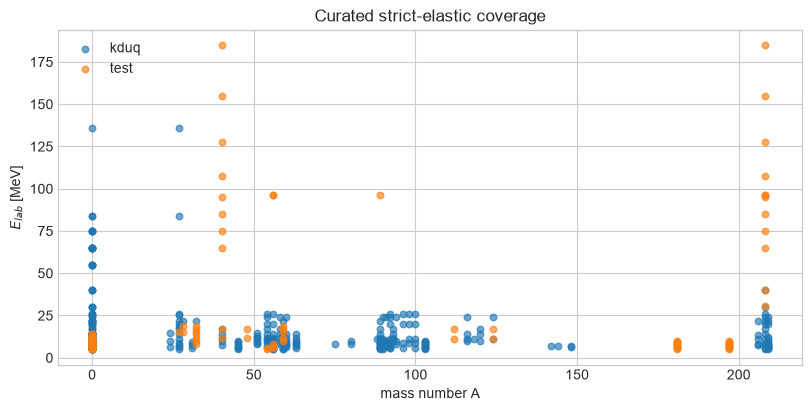

In [3]:
fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
for corpus, group in points.drop_duplicates("record_id").groupby("corpus"):
    ax.scatter(group.A, group.energy_MeV, s=22, alpha=.65, label=corpus)
ax.set(xlabel="mass number A", ylabel=r"$E_{lab}$ [MeV]", title="Curated strict-elastic coverage")
ax.legend()
plt.show()

In [4]:
calcium = points[(points.corpus == "kduq") & (points.target == "Ca-40")]
record_order = (
    calcium[["record_id", "energy_MeV"]].drop_duplicates()
    .sort_values("energy_MeV").reset_index(drop=True)
)
take = np.unique(np.linspace(0, len(record_order)-1, 3, dtype=int))
chosen_ids = record_order.iloc[take].record_id
pilot = calcium[calcium.record_id.isin(chosen_ids)].copy()
pilot.groupby("record_id").agg(energy=("energy_MeV", "first"), points=("angle_cm_deg", "size"))

,energy,points
record_id,,
kduq:12785002:Ca-40:11.91:1,11.910,26
kduq:12785002:Ca-40:9.91:0,9.910,21
kduq:12996002:Ca-40:16.916:3,16.916,27


In [5]:
active = np.asarray([2, 18])  # V1 constant and D1 constant
l_max = 10 if FAST else 16
mesh_points = 400 if FAST else 800
problem = ScatteringProblem(
    potential="kd_neutron", target_a=40, target_z=20,
    lab_energy=float(pilot.energy_MeV.median()), l_max=l_max,
    mesh_points=mesh_points, target_binding_energy=None,
)

def sample_for(a, z, energy, active_values):
    shifts = np.zeros(37); shifts[active] = active_values
    omega = kd_parameters_from_coefficients(a, z, energy, shifts)
    row = dict(zip(KD_PARAMETER_NAMES, np.asarray(omega, float)))
    row.update(A=int(a), Z=int(z), E=float(energy))
    return row

grouped = [group for _, group in pilot.groupby("record_id", sort=False)]

def residuals(active_values, predictor=None):
    residual = []
    for group in grouped:
        row = group.iloc[0]
        sample = sample_for(row.A, row.Z, row.energy_MeV, active_values)
        angles = group.angle_cm_deg.to_numpy(float)
        theory = (problem.cross_section(sample, angles) if predictor is None
                  else predictor.cross_section(sample, angles))
        observed = group.cross_section_mb_sr.to_numpy(float)
        reported = group.point_error_mb_sr.to_numpy(float)
        sigma = np.sqrt(reported**2 + (.02*observed)**2 + (.001*observed.max())**2)
        tau = float(group.normalization_fraction.iloc[0])
        weight = 1.0 / sigma**2
        delta = np.sum(theory*(observed-theory)*weight) / (1/tau**2 + np.sum(theory**2*weight))
        residual.extend((observed-(1+delta)*theory)/sigma)
        residual.append(delta/tau)
    return np.asarray(residual)

fit = least_squares(residuals, np.zeros(len(active)), bounds=(-.08, .08), max_nfev=30 if FAST else 80)
pd.DataFrame({
    "coefficient": [COEFFICIENT_NAMES[i] for i in active],
    "log shift": fit.x,
    "multiplicative change": np.exp(fit.x),
})

,coefficient,log shift,multiplicative change
0,V1 constant,0.007794,1.007824
1,D1 constant,-0.080000,0.923116


In [6]:
# Train a small patch around the FOM optimum. The training interval is
# slightly wider than the selected experimental energies so evaluation
# at the boundary is interpolation, not accidental extrapolation.
e_lo, e_hi = pilot.energy_MeV.min()-1.0, pilot.energy_MeV.max()+1.0
n_train = 120 if FAST else 240
lower = np.r_[e_lo, fit.x-.035]
upper = np.r_[e_hi, fit.x+.035]
design = latin_hypercube(lower, upper, n_train, seed=1204)
train_samples = [sample_for(40, 20, row[0], row[1:]) for row in design]
reference = sample_for(40, 20, float(pilot.energy_MeV.median()), fit.x)
local_problem = ScatteringProblem(
    potential="kd_neutron", target_a=40, target_z=20,
    lab_energy=reference["E"], l_max=l_max, mesh_points=mesh_points,
    target_binding_energy=None,
    reference_omega=np.asarray([reference[name] for name in KD_PARAMETER_NAMES]),
)
training = local_problem.generate_training_data(train_samples)
local_lrom = ScatteringLROM(
    local_problem, BasisConfig(size=6 if FAST else 9),
    MaxVol(count=8 if FAST else 12, ridge=1e-14),
    packing_strategy="padded",
).train(training)
print(f"local LROM trained on {n_train} snapshots across {len(local_problem.channels)} channels")

local LROM trained on 120 snapshots across 21 channels


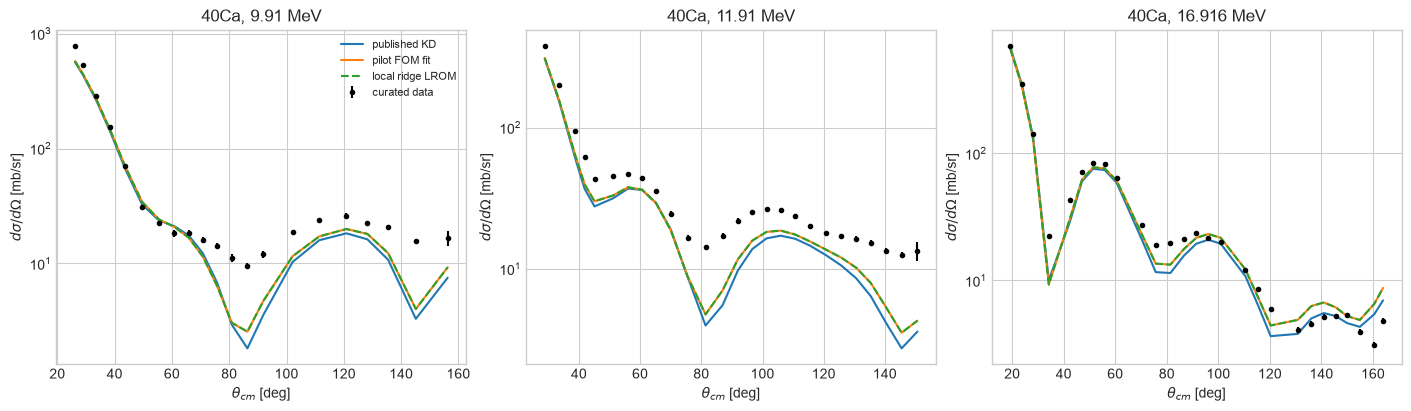

In [7]:
fig, axes = plt.subplots(1, len(grouped), figsize=(14, 4), layout="constrained")
for axis, group in zip(np.atleast_1d(axes), grouped):
    row = group.iloc[0]
    angles = group.angle_cm_deg.to_numpy(float)
    baseline = sample_for(row.A, row.Z, row.energy_MeV, np.zeros(len(active)))
    at_map = sample_for(row.A, row.Z, row.energy_MeV, fit.x)
    axis.errorbar(angles, group.cross_section_mb_sr, yerr=group.point_error_mb_sr,
                  fmt="o", ms=3, color="black", label="curated data")
    axis.semilogy(angles, problem.cross_section(baseline, angles), label="published KD")
    axis.semilogy(angles, problem.cross_section(at_map, angles), label="pilot FOM fit")
    axis.semilogy(angles, local_lrom.cross_section(at_map, angles), "--", label="local ridge LROM")
    axis.set(xlabel=r"$\theta_{cm}$ [deg]", ylabel=r"$d\sigma/d\Omega$ [mb/sr]",
             title=f"40Ca, {row.energy_MeV:g} MeV")
axes[0].legend(fontsize=8)
plt.show()

**Interpretation.** This pilot is useful only if the local LROM follows
the FOM at the optimized point and across a held-out neighborhood. It
is not evidence that two coefficients identify the global potential.
The production study should restore the full isotope/energy corpus,
independent held-out records, hard-routed energy patches, and posterior
predictive checks before sampling all KD coefficients.